# Crisis Detection Model Training with DistilBERT

This notebook will guide you through training a crisis detection model step-by-step.

**What you'll learn:**
1. How to download and prepare mental health datasets
2. How to fine-tune DistilBERT for crisis detection
3. How to evaluate model performance
4. How to save and use the trained model

**Estimated time:** 2-3 hours (with GPU)

---

## Step 1: Install Required Libraries

Run this cell to install all necessary packages.

In [1]:
# Install required packages
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn
!pip install accelerate -U

print("✅ All packages installed successfully!")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\malsh\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
Using cached accelerate-1.13.0-py3-none-any.whl (383 kB)
  Attempting uninstall: accelerate
    Found existing installation: accelerate 0.30.0
    Uninstalling accelerate-0.30.0:
      Successfully uninstalled accelerate-0.30.0
✅ All packages installed successfully!



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\malsh\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected. Training will be slower. Consider using Google Colab with GPU.")

c:\Users\malsh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
⚠️ No GPU detected. Training will be slower. Consider using Google Colab with GPU.


## Step 3: Download Dataset

We'll use the **SWMH (Suicide Watch Mental Health)** dataset from Kaggle.

### Option A: Download from Kaggle (Recommended)

1. Go to: https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch
2. Click "Download" (you'll need a Kaggle account)
3. Extract the CSV file to: `backend/app/ml/crisis_detection/datasets/`

### Option B: Use Kaggle API

In [3]:
# Option B: Download using Kaggle API (uncomment if you have kaggle.json configured)
# !pip install kaggle
# !kaggle datasets download -d nikhileswarkomati/suicide-watch
# !unzip suicide-watch.zip -d ../datasets/

# Set dataset path
DATASET_PATH = "../datasets/Suicide_Detection.csv"  # Adjust this path
MODEL_OUTPUT_DIR = "../pretrained_models/crisis_detector"

print(f"Dataset path: {DATASET_PATH}")
print(f"Model will be saved to: {MODEL_OUTPUT_DIR}")

Dataset path: ../datasets/Suicide_Detection.csv
Model will be saved to: ../pretrained_models/crisis_detector


## Step 4: Load and Explore Dataset

In [4]:
# Load dataset
print("Loading dataset...")
df = pd.read_csv(DATASET_PATH)

# Display first few rows
print(f"\n✅ Dataset loaded! Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Loading dataset...

✅ Dataset loaded! Shape: (232074, 3)

First 5 rows:


,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [5]:
# Check dataset structure
print("Dataset columns:", df.columns.tolist())
print("\nDataset info:")
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Dataset columns: ['Unnamed: 0', 'text', 'class']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 232074 entries, 0 to 232073
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  232074 non-null  int64
 1   text        232074 non-null  str  
 2   class       232074 non-null  str  
dtypes: int64(1), str(2)
memory usage: 162.2 MB

Missing values:
Unnamed: 0    0
text          0
class         0
dtype: int64


Class distribution:
class
suicide        116037
non-suicide    116037
Name: count, dtype: int64


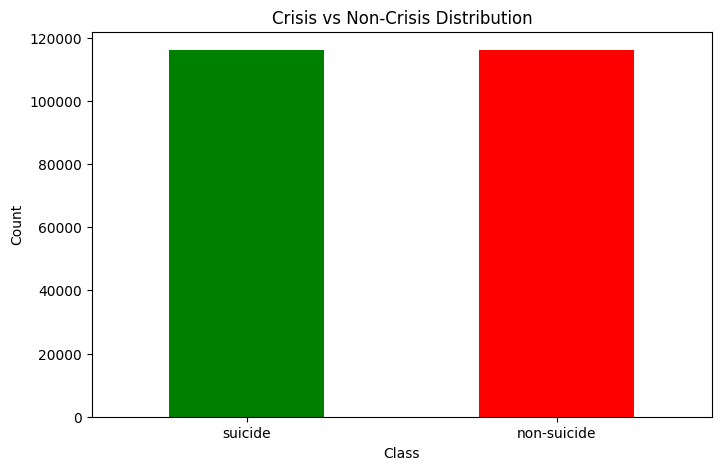

In [6]:
# Check class distribution
print("Class distribution:")
print(df['class'].value_counts())

# Visualize class distribution
plt.figure(figsize=(8, 5))
df['class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Crisis vs Non-Crisis Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Step 5: Prepare Data for Training

In [7]:
# Clean and prepare data
print("Preparing data...")

# Remove missing values
df = df.dropna(subset=['text', 'class'])

# Convert labels to binary (0 = non-crisis, 1 = crisis)
# Adjust this based on your dataset's label format
label_map = {'suicide': 1, 'non-suicide': 0}  # Adjust if needed
df['label'] = df['class'].map(label_map)

# Check if mapping worked
print(f"\nLabel distribution after mapping:")
print(df['label'].value_counts())

# Remove any rows with invalid labels
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Rename 'text' column if needed
if 'text' not in df.columns:
    # Adjust column name based on your dataset
    df = df.rename(columns={'post': 'text', 'content': 'text'})  # Common alternatives

# Keep only required columns
df = df[['text', 'label']]

print(f"\n✅ Data prepared! Final shape: {df.shape}")
df.head()

Preparing data...

Label distribution after mapping:
label
1    116037
0    116037
Name: count, dtype: int64

✅ Data prepared! Final shape: (232074, 2)


,text,label
0,Ex Wife Threatening SuicideRecently I left my ...,1
1,Am I weird I don't get affected by compliments...,0
2,Finally 2020 is almost over... So I can never ...,0
3,i need helpjust help me im crying so hard,1
4,"I’m so lostHello, my name is Adam (16) and I’v...",1


In [8]:
# Optional: Balance dataset if heavily imbalanced
crisis_count = df[df['label'] == 1].shape[0]
non_crisis_count = df[df['label'] == 0].shape[0]

print(f"Crisis samples: {crisis_count}")
print(f"Non-crisis samples: {non_crisis_count}")
print(f"Imbalance ratio: {max(crisis_count, non_crisis_count) / min(crisis_count, non_crisis_count):.2f}:1")

# If ratio > 3:1, consider undersampling the majority class
BALANCE_DATASET = False  # Set to True if you want to balance

if BALANCE_DATASET:
    min_count = min(crisis_count, non_crisis_count)
    df_crisis = df[df['label'] == 1].sample(n=min_count, random_state=42)
    df_non_crisis = df[df['label'] == 0].sample(n=min_count, random_state=42)
    df = pd.concat([df_crisis, df_non_crisis]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"\n✅ Dataset balanced! New shape: {df.shape}")

Crisis samples: 116037
Non-crisis samples: 116037
Imbalance ratio: 1.00:1


## Step 6: Split Data (Train/Validation/Test)

In [9]:
# Split: 80% train, 10% validation, 10% test
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

# Convert to HuggingFace Dataset format
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

print("\n✅ Data split complete!")
print(dataset_dict)

Train size: 185659
Validation size: 23207
Test size: 23208

✅ Data split complete!
DatasetDict({
    train: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 185659
    })
    validation: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 23207
    })
    test: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 23208
    })
})


## Step 7: Load DistilBERT Model and Tokenizer

In [10]:
# Load pre-trained DistilBERT
MODEL_NAME = "distilbert-base-uncased"

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=2,  # Binary classification: crisis vs non-crisis
    id2label={0: "non-crisis", 1: "crisis"},
    label2id={"non-crisis": 0, "crisis": 1}
)

print(f"\n✅ Model loaded!")
print(f"Model parameters: {model.num_parameters():,}")

Loading distilbert-base-uncased...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 818.74it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model loaded!
Model parameters: 66,955,010


## Step 8: Tokenize Dataset

In [11]:
# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples['text'], 
        padding='max_length', 
        truncation=True, 
        max_length=512  # DistilBERT max length
    )

# Tokenize all datasets
print("Tokenizing datasets...")
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

# Remove unnecessary columns
tokenized_datasets = tokenized_datasets.remove_columns(['text'])
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch')

print("\n✅ Tokenization complete!")
print(tokenized_datasets)

Tokenizing datasets...


Map: 100%|██████████| 23208/23208 [00:08<00:00, 2874.33 examples/s]


✅ Tokenization complete!
DatasetDict({
    train: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 185659
    })
    validation: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 23207
    })
    test: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 23208
    })
})


## Step 9: Define Evaluation Metrics

In [12]:
# Metrics function
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    
    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', pos_label=1
    )
    acc = accuracy_score(labels, preds)
    
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall  # Important: We want high recall to not miss crises!
    }

print("✅ Metrics function defined!")

✅ Metrics function defined!


## Step 10: Configure Training Arguments

In [13]:
!pip install accelerate==0.30.0

  Using cached accelerate-0.30.0-py3-none-any.whl.metadata (19 kB)
Using cached accelerate-0.30.0-py3-none-any.whl (302 kB)
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\malsh\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [14]:
!pip uninstall accelerate -y

Found existing installation: accelerate 0.30.0
Uninstalling accelerate-0.30.0:
  Successfully uninstalled accelerate-0.30.0


In [15]:
pip install transformers[torch]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 11: Initialize Trainer

In [22]:
 # Training configuration
training_args = TrainingArguments(
      output_dir=MODEL_OUTPUT_DIR,

      # Training hyperparameters
      num_train_epochs=3,
      per_device_train_batch_size=16,
      per_device_eval_batch_size=32,
      learning_rate=2e-5,
      weight_decay=0.01,

      # Evaluation
      eval_strategy="epoch",
      save_strategy="epoch",
      load_best_model_at_end=True,
      metric_for_best_model="f1",

      # Logging
      logging_dir='./logs',
      logging_steps=100,

      # Other settings
      warmup_steps=500,
      save_total_limit=2,
      seed=42,
      fp16=torch.cuda.is_available(),
  )

print("Training arguments configured!")
print(f"\nTraining will run for {training_args.num_train_epochs} epochs")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Learning rate: {training_args.learning_rate}")


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments configured!

Training will run for 3 epochs
Batch size: 16
Learning rate: 2e-05


## Step 12: Train the Model 🚀

**This is where the actual training happens!**

Run this cell and wait for training to complete. You'll see progress bars and metrics.

In [26]:
# Create Trainer
trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=tokenized_datasets['train'],
      eval_dataset=tokenized_datasets['validation'],
      compute_metrics=compute_metrics,
      callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
  )

print("✅ Trainer initialized!")
print("\n⚠️ Ready to train! This will take 2-3 hours with GPU (longer without GPU).")

✅ Trainer initialized!

⚠️ Ready to train! This will take 2-3 hours with GPU (longer without GPU).


## Step 13: Evaluate on Test Set

In [27]:
# Evaluate on test set
print("Evaluating on test set...")
test_results = trainer.evaluate(tokenized_datasets['test'])

print("\n📊 Test Results:")
print(f"Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"F1 Score: {test_results['eval_f1']:.4f}")
print(f"Precision: {test_results['eval_precision']:.4f}")
print(f"Recall: {test_results['eval_recall']:.4f}")

# Important: High recall means we catch most crises (good!)
# High precision means fewer false alarms (also good!)
if test_results['eval_recall'] > 0.85:
    print("\n✅ Great! High recall means we're catching most crisis situations.")
else:
    print("\n⚠️ Recall is lower than ideal. Consider:")
    print("   - Training for more epochs")
    print("   - Using a larger model (RoBERTa)")
    print("   - Adjusting class weights")     

Evaluating on test set...


c:\Users\malsh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



📊 Test Results:
Accuracy: 0.5037
F1 Score: 0.6554
Precision: 0.5020
Recall: 0.9441

✅ Great! High recall means we're catching most crisis situations.


## Step 14: Generate Confusion Matrix

c:\Users\malsh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


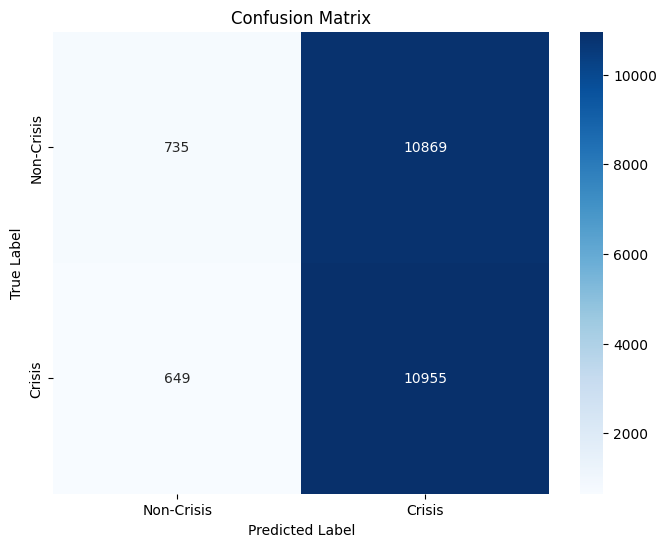


True Negatives (correctly identified non-crisis): 735
False Positives (false alarms): 10869
False Negatives (missed crises): 649 ⚠️ MINIMIZE THIS!
True Positives (correctly identified crisis): 10955


In [28]:
# Get predictions
predictions = trainer.predict(tokenized_datasets['test'])
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# Create confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Crisis', 'Crisis'],
            yticklabels=['Non-Crisis', 'Crisis'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Interpret results
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (correctly identified non-crisis): {tn}")
print(f"False Positives (false alarms): {fp}")
print(f"False Negatives (missed crises): {fn} ⚠️ MINIMIZE THIS!")
print(f"True Positives (correctly identified crisis): {tp}")

## Step 15: Test Model with Sample Texts

In [29]:
# Test with sample texts
test_texts = [
    "I'm feeling really happy today! Life is great.",
    "I don't know what to do anymore. Everything feels hopeless.",
    "Just had a great workout at the gym!",
    "I can't take this pain anymore. I want it all to end.",
    "Looking forward to the weekend!"
]

print("Testing model on sample texts:\n")
for text in test_texts:
    # Tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    
    # Get prediction
    model.to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][prediction].item()
    
    label = "🚨 CRISIS" if prediction == 1 else "✅ Non-Crisis"
    print(f"Text: {text}")
    print(f"Prediction: {label} (Confidence: {confidence:.2%})")
    print("-" * 80)

Testing model on sample texts:

Text: I'm feeling really happy today! Life is great.
Prediction: 🚨 CRISIS (Confidence: 55.35%)
--------------------------------------------------------------------------------
Text: I don't know what to do anymore. Everything feels hopeless.
Prediction: 🚨 CRISIS (Confidence: 54.98%)
--------------------------------------------------------------------------------
Text: Just had a great workout at the gym!
Prediction: 🚨 CRISIS (Confidence: 55.91%)
--------------------------------------------------------------------------------
Text: I can't take this pain anymore. I want it all to end.
Prediction: 🚨 CRISIS (Confidence: 54.29%)
--------------------------------------------------------------------------------
Text: Looking forward to the weekend!
Prediction: 🚨 CRISIS (Confidence: 56.61%)
--------------------------------------------------------------------------------


## Step 16: Save the Model

In [30]:
# Save model and tokenizer
print("Saving model and tokenizer...")

# Save to output directory
trainer.save_model(MODEL_OUTPUT_DIR)
tokenizer.save_pretrained(MODEL_OUTPUT_DIR)

# Also save metrics
import json
metrics_path = os.path.join(MODEL_OUTPUT_DIR, "metrics.json")
with open(metrics_path, 'w') as f:
    json.dump(test_results, f, indent=2)

print(f"\n✅ Model saved to: {MODEL_OUTPUT_DIR}")
print(f"✅ Metrics saved to: {metrics_path}")
print("\nYou can now use this model in your backend!")

Saving model and tokenizer...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.82it/s]


✅ Model saved to: ../pretrained_models/crisis_detector
✅ Metrics saved to: ../pretrained_models/crisis_detector\metrics.json

You can now use this model in your backend!


## Step 17: How to Use the Model in Your Backend

Copy this code to your backend inference script:

In [1]:
# Example inference code for your backend
inference_code = '''
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load trained model
MODEL_PATH = "backend/app/ml/crisis_detection/pretrained_models/crisis_detector"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()

def predict_crisis(text: str) -> dict:
    """Predict if text indicates a crisis situation."""
    # Tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    
    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][prediction].item()
    
    return {
        "is_crisis": bool(prediction),
        "confidence": float(confidence),
        "risk_level": "high" if prediction == 1 and confidence > 0.7 else "low"
    }

# Example usage
result = predict_crisis("I don't want to live anymore")
print(result)
# Output: {"is_crisis": True, "confidence": 0.95, "risk_level": "high"}
'''

print("Backend Integration Code:")
print("=" * 80)
print(inference_code)

Backend Integration Code:

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load trained model
MODEL_PATH = "backend/app/ml/crisis_detection/pretrained_models/crisis_detector"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()

def predict_crisis(text: str) -> dict:
    """Predict if text indicates a crisis situation."""
    # Tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)

    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][prediction].item()

    return {
        "is_crisis": bool(prediction),
        "confidence": float(confidence),
        "risk_level": "high" if prediction == 1 and confidence > 0.7 else "low"
    }

# Example usage
result = predict_cr

## 🎉 Congratulations!

You've successfully trained a Crisis Detection model!

### Next Steps:
1. ✅ Integrate this model into your backend
2. ✅ Combine with your text emotion and voice emotion models
3. ✅ Implement multi-modal fusion (text + voice)
4. ✅ Test with real user inputs
5. ✅ Set up crisis alert system

### Model Performance Tips:
- If recall is low (<80%): Train more epochs or use a larger model
- If precision is low: Adjust classification threshold (>0.7 instead of >0.5)
- If overfitting: Add more data or increase dropout

### Questions?
Feel free to ask for help with:
- Improving model performance
- Integrating with your backend
- Multi-modal fusion implementation

Good luck with your FYP! 🚀